# BMWP Fuzzy Model — Spearman Validation

External validation of the fuzzy BMWP predictions against the observed BMWP/Col index
using Spearman's rank correlation, comparing the original in-sample fuzzy system with
the redesigned LOOCV fuzzy system.

## 1. Introduction

This notebook compares observed BMWP values per sampling station against fuzzy-model
predictions using Spearman's rank correlation. Two evaluations are contrasted: the
original fuzzy system on its in-sample data (n = 14) and the redesigned fuzzy system
(Approach E, FCM + 3 predictors) under LOOCV, whose per-fold predictions are produced
by `01f_fuzzy_final.ipynb`.

## 2. Dependencies and Data Loading

Observed vs original-fuzzy-predicted BMWP per station (transcribed from the original
fuzzy run, n = 14).

In [1]:
# Imports and global plotting style
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [2]:
# Observed vs original-fuzzy-predicted BMWP per station (in-sample, n=14)
data = {
    "BMWP": [116, 96, 94, 93, 90, 85, 75, 72, 65, 52, 37, 28, 20, 13],
    "Prediction": [95.81, 87.33, 87.33, 87.33, 87.33, 87.33, 95.81, 87.33,
                   87.33, 52.33, 52.33, 28.67, 28.67, 5.00],
    "Station": ["RA1 (1)", "RA1 (2)", "RC1 (1)", "RC1 (2)", "RF3 (1)", "RA2 (2)",
                "RC2 (2)", "RA2 (1)", "RF2 (2)", "RF2 (1)", "RF3 (2)", "RA3 (1)",
                "RC4 (1)", "RC4 (2)"],
}
df = pd.DataFrame(data)
print(df.to_string(index=False))

 BMWP  Prediction Station
  116       95.81 RA1 (1)
   96       87.33 RA1 (2)
   94       87.33 RC1 (1)
   93       87.33 RC1 (2)
   90       87.33 RF3 (1)
   85       87.33 RA2 (2)
   75       95.81 RC2 (2)
   72       87.33 RA2 (1)
   65       87.33 RF2 (2)
   52       52.33 RF2 (1)
   37       52.33 RF3 (2)
   28       28.67 RA3 (1)
   20       28.67 RC4 (1)
   13        5.00 RC4 (2)


## 3. In-sample Spearman correlation (original fuzzy system)

The original fuzzy rules were derived from the same 14 observations used here, so this
result reflects **in-sample** performance. The BMWP/Col quality bands are drawn as a
coloured background.

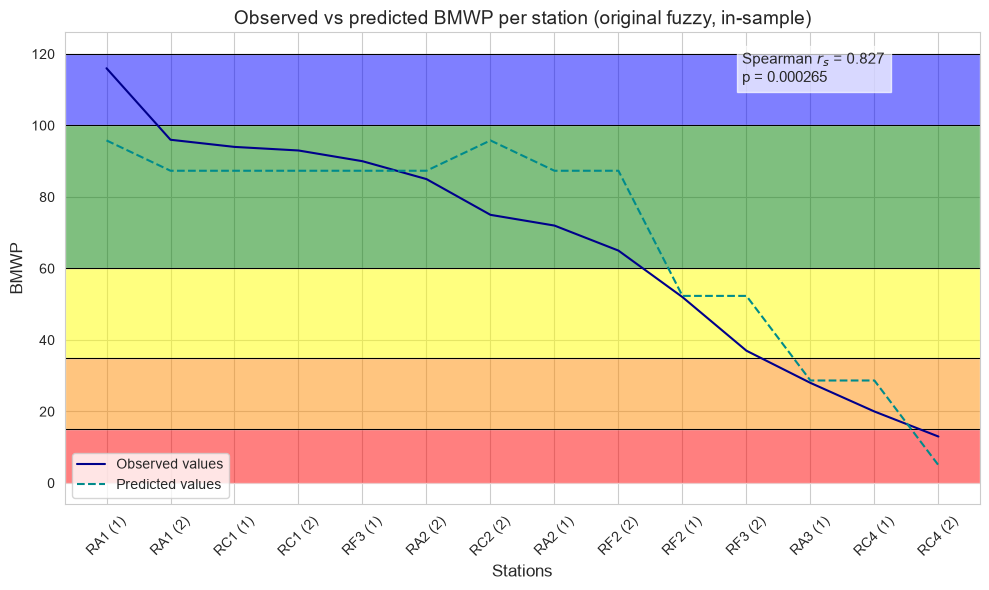

In-sample Spearman rs = 0.827 (p = 0.000265)


In [3]:
# In-sample Spearman correlation and per-station line plot with BMWP/Col bands
spearman_corr, p_value = spearmanr(df["BMWP"], df["Prediction"])

plt.figure(figsize=(10, 6))
colors = ['red', 'darkorange', 'yellow', 'green', 'blue']
ranges = [15, 35, 60, 100]
for i in range(len(ranges) + 1):
    lo = 0 if i == 0 else ranges[i - 1]
    hi = 120 if i == len(ranges) else ranges[i]
    plt.axhspan(lo, hi, facecolor=colors[i], alpha=0.5)
    plt.axhline(y=hi, color='black', linewidth=0.8)

plt.plot(df["Station"], df["BMWP"], label="Observed values", color="darkblue", linestyle="-")
plt.plot(df["Station"], df["Prediction"], label="Predicted values", color="darkcyan", linestyle="--")
plt.xlabel("Stations", fontsize=12); plt.ylabel("BMWP", fontsize=12)
plt.title("Observed vs predicted BMWP per station (original fuzzy, in-sample)", fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.legend(fontsize=10, loc='lower left')
plt.text(0.74, 0.96, f"Spearman $r_s$ = {spearman_corr:.3f}\np = {p_value:.6f}",
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.7))
plt.tight_layout()
plt.savefig("../../outputs/bmwp_spearman.png", dpi=300)
plt.show()
print(f"In-sample Spearman rs = {spearman_corr:.3f} (p = {p_value:.6f})")

## 4. Side-by-side comparison: in-sample vs LOOCV

The redesigned per-fold predictions are loaded from
`outputs/fuzzy_final_bmwp_loocv_predictions.csv` (produced by `01f_fuzzy_final.ipynb`).
Each panel is an observed-vs-predicted scatter with the 1:1 line and BMWP/Col bands.

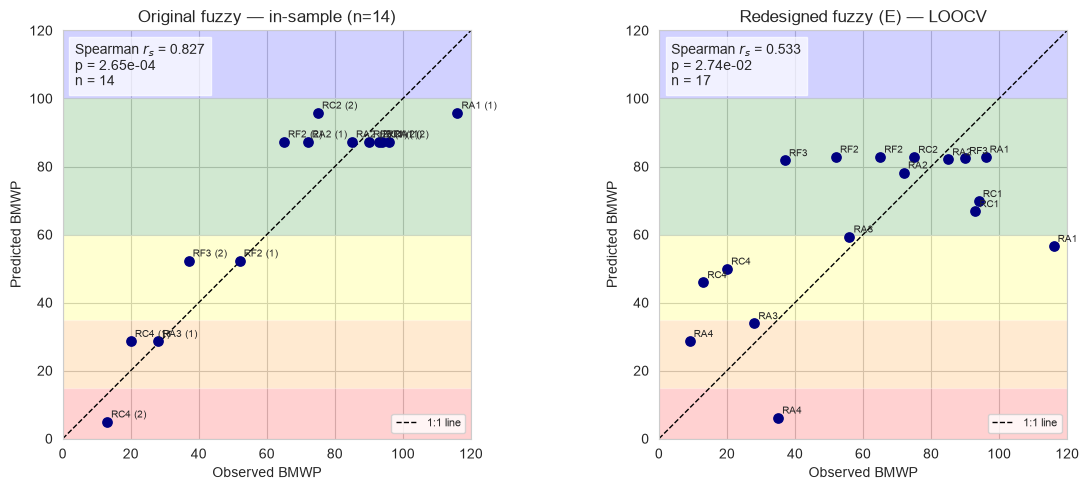

In-sample (n=14): rs = 0.827, p = 0.000265
LOOCV     (n=17): rs = 0.533, p = 0.027448


In [4]:
# Side-by-side Spearman comparison: original in-sample (n=14) vs redesigned LOOCV
loocv = pd.read_csv("../../outputs/fuzzy_final_bmwp_loocv_predictions.csv")
rs_in, p_in = spearmanr(df["BMWP"], df["Prediction"])
rs_lo, p_lo = spearmanr(loocv["Observed_BMWP"], loocv["Predicted_BMWP"])
bands = [(0, 15, 'red'), (15, 35, 'darkorange'), (35, 60, 'yellow'),
         (60, 100, 'green'), (100, 120, 'blue')]

def panel(ax, obs, pred, labels, rs, pval, n, title):
    for lo, hi, col in bands:
        ax.axhspan(lo, hi, facecolor=col, alpha=0.18)
    ax.plot([0, 120], [0, 120], 'k--', lw=1, label='1:1 line')
    ax.scatter(obs, pred, color='navy', s=45, zorder=3)
    for x, y, lab in zip(obs, pred, labels):
        ax.annotate(str(lab), (x, y), fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_xlim(0, 120); ax.set_ylim(0, 120); ax.set_aspect('equal')
    ax.set_xlabel("Observed BMWP"); ax.set_ylabel("Predicted BMWP"); ax.set_title(title)
    ax.text(0.03, 0.97, f"Spearman $r_s$ = {rs:.3f}\np = {pval:.2e}\nn = {n}",
            transform=ax.transAxes, va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
    ax.legend(loc='lower right', fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
panel(axes[0], df["BMWP"], df["Prediction"], df["Station"], rs_in, p_in, len(df),
      "Original fuzzy — in-sample (n=14)")
panel(axes[1], loocv["Observed_BMWP"], loocv["Predicted_BMWP"], loocv["Station"],
      rs_lo, p_lo, len(loocv), "Redesigned fuzzy (E) — LOOCV")
plt.tight_layout()
plt.savefig("../../outputs/bmwp_spearman_comparison.png", dpi=300)
plt.show()
print(f"In-sample (n={len(df)}): rs = {rs_in:.3f}, p = {p_in:.6f}")
print(f"LOOCV     (n={len(loocv)}): rs = {rs_lo:.3f}, p = {p_lo:.6f}")

## 5. Numerical performance export (original in-sample)

MAE, RMSE and R² of the original fuzzy predictions against observed BMWP, exported for
the master results table (Table C).

In [5]:
# Numerical metrics for the original in-sample fuzzy predictions and export
obs = df["BMWP"].to_numpy(dtype=float)
pred = df["Prediction"].to_numpy(dtype=float)
mae = mean_absolute_error(obs, pred)
rmse = float(np.sqrt(np.mean((obs - pred) ** 2)))
r2 = r2_score(obs, pred)
rs, p = spearmanr(obs, pred)
print(f"In-sample fuzzy: MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² = {r2:.3f}, rs = {rs:.3f} (p = {p:.6f})")
pd.DataFrame([{'model': 'Fuzzy original', 'validation': 'In-sample', 'n': len(df),
               'mae': round(mae, 2), 'rmse': round(rmse, 2), 'r2': round(r2, 3),
               'rs': round(rs, 3), 'p_value': round(p, 6)}]
             ).to_csv("../../outputs/numerical_bmwp_insample.csv", index=False)
print("Saved outputs/numerical_bmwp_insample.csv")

In-sample fuzzy: MAE = 9.83, RMSE = 12.29, R² = 0.842, rs = 0.827 (p = 0.000265)
Saved outputs/numerical_bmwp_insample.csv


## 9. Limitations

- **In-sample reference.** The original fuzzy rs (0.827) reflects rules derived from
  the same 14 stations used for the comparison and must not be read as out-of-sample
  skill; the LOOCV rs is the honest estimate.
- **Rank-only.** Spearman captures monotonic agreement, not absolute error; the
  numerical metrics (MAE/RMSE/R²) and Section 7 of `01f`/`04` complete the picture.
- **Small sample.** With 14–17 station pairs the correlation has wide uncertainty.